# Wildfire Risk: the leak, the split, the threshold

Three things decide whether a model on this dataset means anything. All three are
demonstrated below rather than asserted.

1. **Three columns leak the label perfectly** — one of them turns an honest 0.56 into 1.000.
2. **A random split inflates the score** and collapses the fold spread, making a fragile
   estimate look settled.
3. **The default 0.5 threshold misses two fires in three**, and the precision you measure
   is about 20x the precision you would actually deploy.

Runs in roughly two minutes. Fork it and beat 0.559.

In [1]:
import glob

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import (average_precision_score, f1_score, precision_score,
                             recall_score, roc_auc_score)

hits = glob.glob("/kaggle/input/**/dataset.parquet", recursive=True)
d = pd.read_parquet(hits[0] if hits else "data/processed/dataset.parquet")

NOT_FEATURES = [
    "sample_kind", "n_detections", "max_frp",   # leak the label - see below
    "cell_id", "lat", "lon",                    # geography - see below
    "date", "year", "doy", "split",             # keys and bookkeeping
    "label",                                    # the target
]
FEATURES = [c for c in d.columns if c not in NOT_FEATURES]
X, y, years = d[FEATURES], d["label"], d["year"]

print(f"{len(d):,} rows x {d.shape[1]} columns  ->  {len(FEATURES)} model features")
print(f"positives {y.mean()*100:.1f}%  |  {d.cell_id.nunique():,} cells  |  "
      f"{d.year.min()}-{d.year.max()}")
d.head(3)

121,869 rows x 32 columns  ->  21 model features
positives 24.9%  |  1,423 cells  |  2012-2025


,cell_id,lat,lon,date,year,doy,label,sample_kind,n_detections,max_frp,...,temp_max_7d_mean,rh_min_7d_mean,ffmc,dmc,dc,isi,bui,fwi,days_since_last_fire,split
0,340_60,34.0,6.0,2013-06-27,2013,178,0,matched_negative,0,NaN,...,36.571429,20.714286,96.275582,520.481620,825.167243,34.680699,515.655797,85.693776,9999.0,train
1,340_60,34.0,6.0,2013-07-04,2013,185,0,matched_negative,0,NaN,...,35.928571,21.000000,96.815177,570.881945,895.465243,24.668329,565.143193,70.063644,9999.0,train
2,340_60,34.0,6.0,2013-07-15,2013,196,0,matched_negative,0,NaN,...,39.428571,16.428571,98.304000,652.497693,1011.287243,39.857688,645.171948,92.909470,9999.0,train


---
## 1. The leak

`sample_kind`, `n_detections` and `max_frp` describe the fire that was detected. They only
have values *because* a fire happened, so they encode the answer.

Watch what one of them does to an otherwise honest model.

In [2]:
tr, te = d.year < 2024, d.year >= 2024
quick = dict(objective="binary", n_estimators=200, learning_rate=0.05,
             num_leaves=63, n_jobs=-1, verbose=-1, random_state=42)

for name, feats in [("21 model features", FEATURES),
                    ("  ... plus n_detections", FEATURES + ["n_detections"])]:
    m = lgb.LGBMClassifier(**quick).fit(d.loc[tr, feats], d.loc[tr, "label"])
    p = m.predict_proba(d.loc[te, feats])[:, 1]
    print(f"{name:<26} PR-AUC {average_precision_score(d.loc[te, 'label'], p):.4f}")

21 model features          PR-AUC 0.1961


  ... plus n_detections    PR-AUC 1.0000


A perfect 1.000 — the model has stopped reading the weather and started reading the label.

*(The honest score here looks low against the 0.559 further down. That is not a
contradiction: 2024 and 2025 have unusually low base rates — 7.6% and 13.3% against 24.9%
overall — and PR-AUC is measured relative to the base rate, so it is never comparable
across different splits. Compare models within a split, not across. A leaked 1.000 is
comparable to everything, which is rather the point.)*

`n_detections` is exactly 0 for every negative. `max_frp` is NaN for every negative.
`sample_kind` literally spells out which class the row is. Any one of them alone is enough,
and none of them would exist at prediction time in the real world.

**`lat`/`lon` are excluded too**, for a different reason. Every negative was drawn from the
*same cell* as a positive on a different day, so cell identity is statistically independent
of the label (per-cell positive rate sd = 0.0074). Coordinates carry no signal here by
construction — they would only let the model memorise sampling noise.

---
## 2. The split

One wildfire burns for several days, and its cell-days are near-duplicates. A random split
puts the same fire on both sides of the boundary.

In [3]:
def cross_validate(params, X, y, groups, random_split=False):
    """5-fold CV. random_split=True exists only to show what leakage looks like."""
    splitter = (KFold(5, shuffle=True, random_state=42).split(X)
                if random_split else GroupKFold(5).split(X, y, groups))
    oof, rows = np.zeros(len(X)), []
    for tr, te in splitter:
        m = lgb.LGBMClassifier(**params).fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[te])[:, 1]
        oof[te] = p
        rows.append({"pr_auc": average_precision_score(y.iloc[te], p),
                     "roc_auc": roc_auc_score(y.iloc[te], p)})
    return pd.DataFrame(rows), oof


grouped, _ = cross_validate(quick, X, y, years)
leaky, _ = cross_validate(quick, X, y, years, random_split=True)

print(f"a random split overstates PR-AUC by "
      f"{(leaky.pr_auc.mean()/grouped.pr_auc.mean() - 1)*100:.0f}%")
print(f"and reports a fold spread {grouped.pr_auc.std()/leaky.pr_auc.std():.0f}x too tight")

pd.DataFrame({
    "random split (leaky)": [leaky.pr_auc.mean(), leaky.pr_auc.std()],
    "grouped by year (honest)": [grouped.pr_auc.mean(), grouped.pr_auc.std()],
}, index=["PR-AUC", "fold sd"]).T.round(4)

a random split overstates PR-AUC by 9%
and reports a fold spread 21x too tight


,PR-AUC,fold sd
random split (leaky),0.6072,0.0036
grouped by year (honest),0.5564,0.0767


The inflated mean is the obvious problem. **The collapsed fold spread is the worse one** —
random folds all look alike because each holds fragments of the same fires, so a fragile
estimate looks settled. Year-grouped folds disagree because seasons genuinely differ, and
that disagreement is the real uncertainty.

(On weather features alone the gap is wider still: 0.4594 grouped against 0.5567 random,
a 21% overstatement. The fuel feature narrows it because it is less season-specific.)

Group by `year`. Everything below does.

---
## 3. The baseline to beat

In [4]:
TUNED = dict(objective="binary", n_estimators=1275, learning_rate=0.0146,
             num_leaves=29, min_child_samples=197, subsample=0.5998,
             subsample_freq=1, colsample_bytree=0.7671, reg_alpha=0.0667,
             reg_lambda=3.2759, n_jobs=-1, verbose=-1, random_state=42)

folds, oof = cross_validate(TUNED, X, y, years)
print(f"PR-AUC {folds.pr_auc.mean():.4f} +/- {folds.pr_auc.std():.3f}    "
      f"ROC-AUC {folds.roc_auc.mean():.4f}")
folds.round(4)

PR-AUC 0.5594 +/- 0.074    ROC-AUC 0.7814


,pr_auc,roc_auc
0,0.6719,0.8054
1,0.5244,0.7755
2,0.4772,0.7765
3,0.5893,0.7856
4,0.5341,0.7642


Note the per-fold spread: some seasons are far easier than others. That is why a single
number quoted without its uncertainty is misleading here.

---
## 4. What the model actually uses

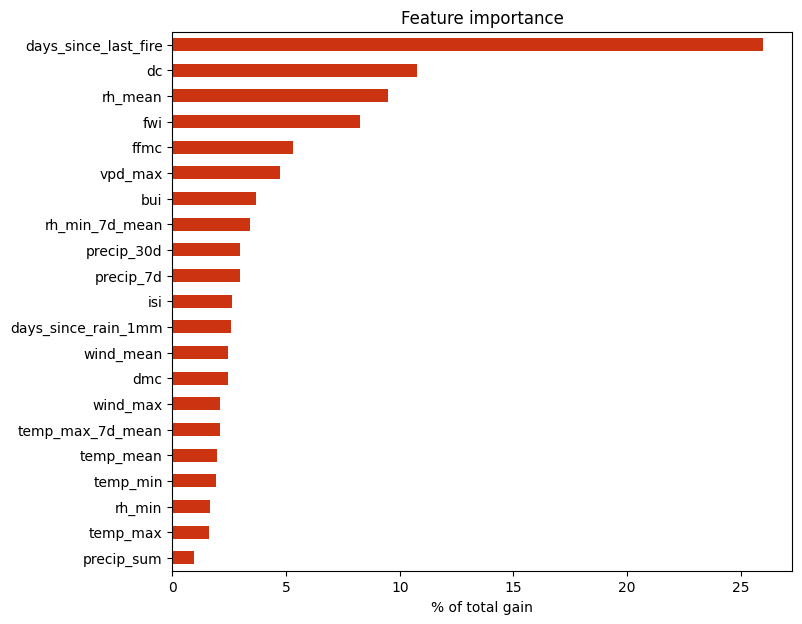

,gain_%
days_since_last_fire,26.0
dc,10.8
rh_mean,9.5
fwi,8.2
ffmc,5.3


In [5]:
m = lgb.LGBMClassifier(**TUNED).fit(X, y)
imp = pd.Series(m.booster_.feature_importance("gain"), index=FEATURES)
imp = (imp / imp.sum() * 100).sort_values()

ax = imp.plot(kind="barh", figsize=(8, 7), color="#cc3311")
ax.set_xlabel("% of total gain")
ax.set_title("Feature importance")
plt.show()

imp.sort_values(ascending=False).head(5).round(1).to_frame("gain_%")

`days_since_last_fire` dominates. Burned ground does not reburn for months, and nothing in
the weather knows that — 20 weather and fire-weather-index features reach 0.459, and this
one feature takes it to 0.551.

It carries a **mandatory 4-day lag**, which is why its minimum is 5 rather than 0. Without
the lag, every value below 4 is 100% positive by sampling construction and PR-AUC inflates
to 0.688 on pure artefact. If you recompute this feature from other fire data, keep the lag.

---
## 5. The threshold matters more than the model

`predict()` uses 0.5. Look at what that costs.

In [6]:
n_pos = int(y.sum())
rows = []
for t in [0.10, 0.15, 0.18, 0.25, 0.50, 0.70]:
    yhat = (oof >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y, yhat, zero_division=0),
        "recall": recall_score(y, yhat, zero_division=0),
        "f1": f1_score(y, yhat, zero_division=0),
        "fires_missed": n_pos - int(((yhat == 1) & (y == 1)).sum()),
        "false_alarms": int(((yhat == 1) & (y == 0)).sum()),
    })
pd.DataFrame(rows).round(4)

,threshold,precision,recall,f1,fires_missed,false_alarms
0,0.10,0.3193,0.9352,0.4761,1966,60507
1,0.15,0.3603,0.8604,0.5079,4238,46355
2,0.18,0.3864,0.8097,0.5232,5777,39017
3,0.25,0.4494,0.6898,0.5442,9416,25648
4,0.50,0.6519,0.3201,0.4294,20636,5187
5,0.70,0.7943,0.1249,0.2159,26559,982


At 0.5 the model misses roughly two fires in three. Moving to 0.18 catches 81% of them.

For fire risk a missed fire and a false alarm are not equally bad, so F1 — which weights
them equally — is the wrong thing to optimise. Pick a **recall target** and read off the
threshold that meets it.

---
## 6. The precision above is not the precision you would deploy

Training data is 1:3 by construction. Real fire-days are about **1 in 100** eligible
cell-days in season. The model behaves identically in both worlds, but the number of
non-fire days available to generate false alarms changes by 25x.

In [7]:
SAMPLED = float(y.mean())
REAL = 0.00996          # ~1 fire-day per 100 eligible cell-days in season


def correct(p, sampled=SAMPLED, real=REAL):
    """Prior shift. Sampling changed the base rate, not the evidence."""
    p = np.clip(np.asarray(p, float), 1e-9, 1 - 1e-9)
    odds = (p / (1 - p)) * ((real / (1 - real)) / (sampled / (1 - sampled)))
    return odds / (1 + odds)


measured = precision_score(y, (oof >= 0.18).astype(int), zero_division=0)
deployed = float(correct(measured))
print(f"precision at 0.18, as measured : {measured:.3f}")
print(f"corrected to the real base rate: {deployed:.3f}   "
      f"(about 1 alert in {1/deployed:.0f})")

adj = correct(oof)
bands = pd.cut(adj / REAL, [0, 1, 3, 8, np.inf], include_lowest=True,
               labels=["Low", "Moderate", "High", "Extreme"])
tab = pd.crosstab(bands, y)
tab.columns = ["no fire", "fire"]
tab["fire rate %"] = (tab["fire"] / tab.sum(axis=1) * 100).round(1)
tab

precision at 0.18, as measured : 0.386
corrected to the real base rate: 0.019   (about 1 alert in 53)


,no fire,fire,fire rate %
row_0,,,
Low,65738,9378,12.5
Moderate,20707,11385,35.5
High,4452,6863,60.7
Extreme,621,2725,81.4


Recall transfers between the two worlds; precision does not. Recall only involves actual
fires, and every one of those was kept. Precision depends on how many negatives exist, and
most of those were discarded.

So the usable output is not a probability — it is the **ranking**. Bands expressed as
multiples of the base rate climb from 12.5% to 81.4% fire rate, and that ordering is what
an application would act on.

---
## Where the headroom is

Already measured on this data, all inside or below the +/-0.074 fold noise:

| Attempt | Result |
|---|---|
| Five model families (LightGBM, XGBoost, RF, ExtraTrees, MLP) | spread of 0.013 |
| Hyperparameter tuning | 0.551 -> 0.559 |
| Feature scaling | 0.0004 |
| Class weighting / undersampling to 50/50 | +0.001 / -0.002 |
| Predicting "fire within 3 days" instead of today | **-0.06** |

Unrelated model families converging that tightly is an **information ceiling**, not an
algorithmic one. More capacity will not move it.

What is missing is **fuel state**. The model knows how dry the air is and when the cell
last burned, but nothing about whether there is vegetation there to burn or how cured it
is. NDVI and NDMI are the open lever — and note that raw NDVI will mostly not work here,
because it is dominated by which cell you are in, which the matched sampling has already
neutralised. Use anomalies against each cell's own seasonal norm.

Pipeline, FWI implementation and full modelling notebooks:
**https://github.com/Abdelmalek05/fire-detection-model**